# **Generative Adversial Networks**

A *Generative Adversial Network* or *GAN* is an unsupervised model that aims to generate new samples that are indistinguishable from a set of training examples. GANs are mechanisms to create new samples; they do not build a probability distribution over the modeled data and hence cannot evaluate the probability that a new data point belongs to the same distribution.

**Generator:** the role of the generator is to find a mapping from a known distribution (latent space, $p_z(x)$) to the target distribution ($p_{\theta}(x)$), but to ensure that the mapped points come from the real distribution of data.

| 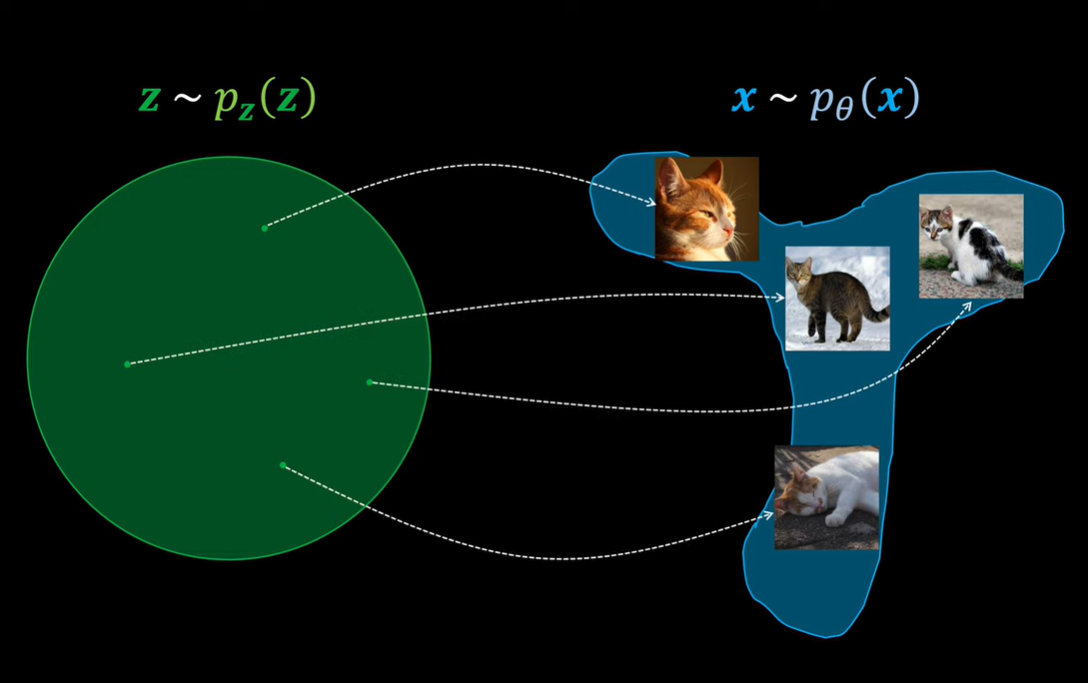 | 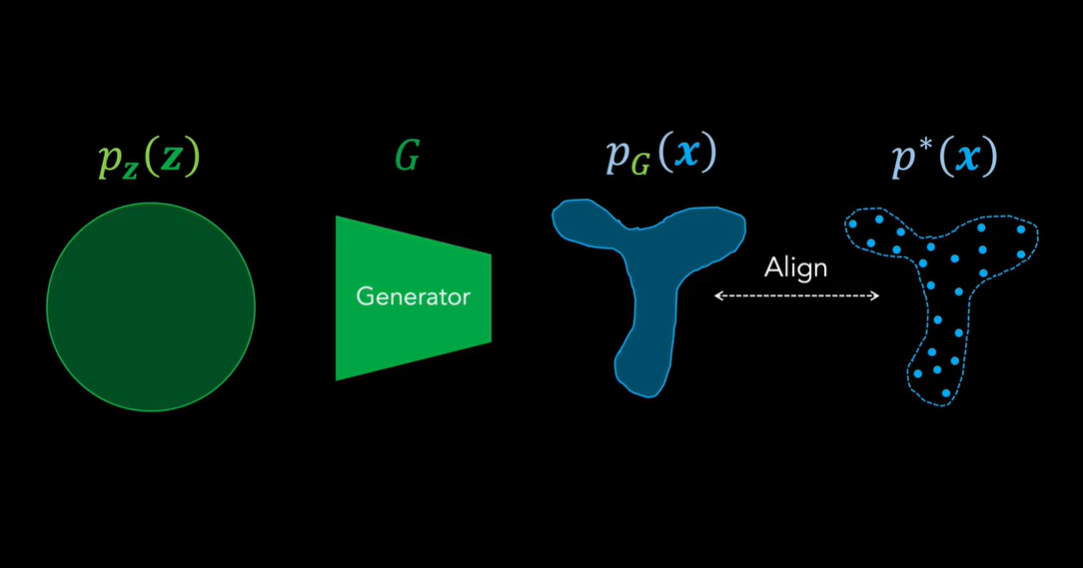 |
|:---:|:---:|

**Discriminator:** the role of the discriminator is to act as a binary classifier that tries to distinguish between real samples (from the training data) and fake samples (produced by the generator). Formally, given an input $x$, the discriminator outputs a probability $D(x) \in [0, 1]$ such that $x$ comes from the real distribution:
- $D(x) = 1$ means the discriminator belives $x$ is real
- $D(x) = 0$ means it belives $x$ is generated (fake)

$
\begin{equation}
 D(y|x) =
  \begin{cases}
  D(x)     & \text{if } y = 1 \\
  1 - D(x) & \text{if } y = 0
  \end{cases}
\end{equation}
$

$
\begin{equation}
 p_b^*(y | x) =
  \begin{cases}
  y      & \text{if } x \sim p^*(x) \\
  \neg y & \text{if } x \sim p_g(x)
  \end{cases}
\end{equation}
$

where $p^*(x)$ is the real data distribution and $p_g(x)$ is the generated distribution by generator $G$.

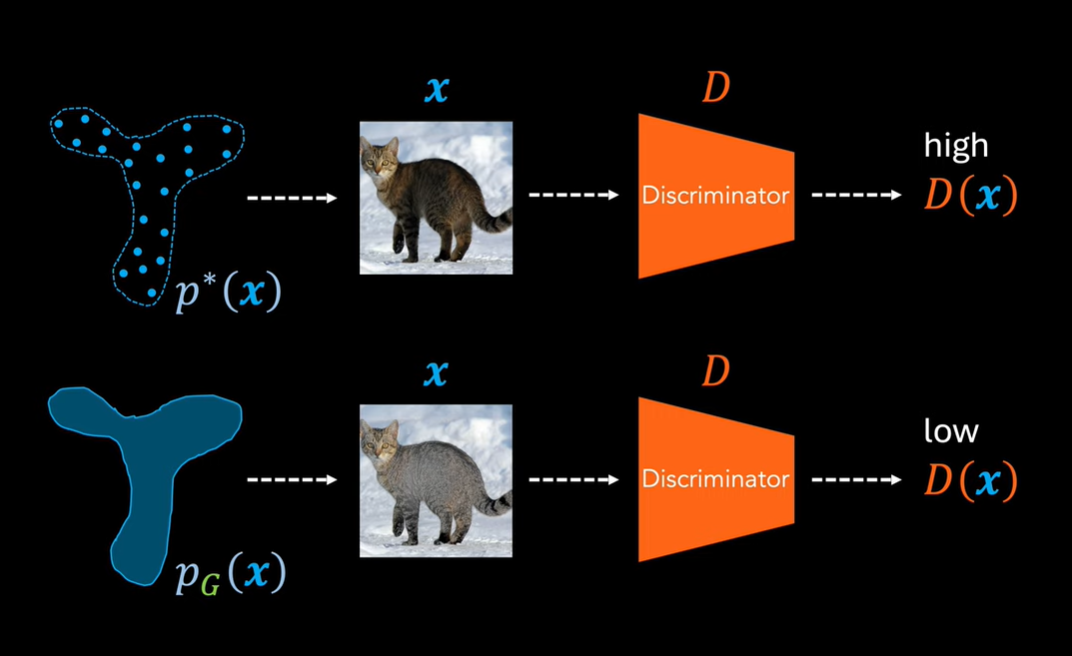

The main goal of the GAN is to align the distributions $D(y|x)$ and $p_b^*(y|x)$, and to do this, it needs to minimize the KL divergence:

$$D_{KL}(p_b^* || D) = \mathbb{E}_{y \sim p_b^*(y|x)} log(\frac{p_b^*(y|x)}{D(y|x)})$$

Since we know that the $y$ labels are discrete, the divergence can be reformulated as:

$$D_{KL}(p_b^* || D) = \sum_y p_b^*(y|x) log(\frac{p_b^*(y|x)}{D(y|x)})$$

If we decompose the fraction inside the logarithm we get:

$$D_{KL}(p_b^* || D) = \sum_y p_b^*(y|x) log p_b^*(y|x) - \sum_y p_b^*(y|x) log D(y|x)$$

The left term is constant with respect to D, so we can ignore it in the training objective:

$$D_{KL}(p_b^* || D) =  - \sum_y p_b^*(y|x) log D(y|x), \text{ which is the cross-entropy} $$

It can be simplified even more, since there are only two value of $y$:

$$D_{KL}(p_b^* || D) =  - p_b^*(0|x) log D(0|x) - p_b^*(1|x) log D(1|x)$$
$$L =  -(1 - p_b^*(1|x)) log(1 - D(x)) - p_b^*(1|x) log D(x), \text{ which is the binary cross-entropy}$$

To actually train the discriminator, it needs to be run on a classification task and to be able to distinguish between real and generated samples.

$$ L_D = \mathbb{E}_{x \sim p*} [L_{BCE}] + \mathbb{E}_{x \sim p_G} [L_{BCE}] $$
$$ L_{BCE} = -(1 - p_b^*(1|x)) log(1 - D(x)) - p_b^*(1|x) log D(x) $$

And there are two cases:
- $x \sim p*$:  which makes $p_b^*(1|x) = 1$, therefore $L = -log D(x)$
- $x \sim p_G$: which makes $p_b^*(1|x) = 0$, therefore $L = -log (1 - D(x))$

$$ L_D = -\mathbb{E}_{x \sim p^*} [log D(x)] - \mathbb{E}_{x \sim p_G} [log (1 - D(x))] $$

Finally: 

$ L_D = -\mathbb{E}_{x \sim p^*} [log D(x)] - \mathbb{E}_{z \sim p_z} [log (1 - D(G(z)))] $

$ L_G = -L_D = \mathbb{E}_{z \sim p_z} [log(1 - D(G(z)))] $

In [29]:
import argparse
import os
import random
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

manual_seed = 999
print("Random Seed: ", manual_seed)
random.seed(manual_seed)
torch.manual_seed(manual_seed)
torch.use_deterministic_algorithms(True) 

Random Seed:  999


## **Inputs**

Definition of some inputs for the run:
- **dataroot**: the path to the root of the dataset folder
- **workers**: the number of workers threads for loading the data with *DataLoader*
- **batch_size**: the batch size used during training
- **image_size**: the spatial size of the images used for training (64 x 64)
- **nc**: number of color channels in the inputs images (3)
- **nz**: length of the *latent vector*
- **ngf**: the depth of features maps carried through the generator
- **ndf**: the depth of features maps propagated through the discriminator
- **num_epochs**: number of training epochs to run
- **lr**: learning rate for training
- **beta1**: for Adam optimizers
- **ngpu**: number of GPUs available


In [30]:
dataroot = "data/celeba"
workers = 2
batch_size = 128
image_size = 64
nc = 1
nz = 100
ngf = 64
ndf = 64
num_epochs = 5
lr = 0.0002
beta1 = 0.5
ngpu = 1

In [31]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Working on {device}")

transform = transforms.Compose([
    transforms.Resize(64),         
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

Working on cuda:0


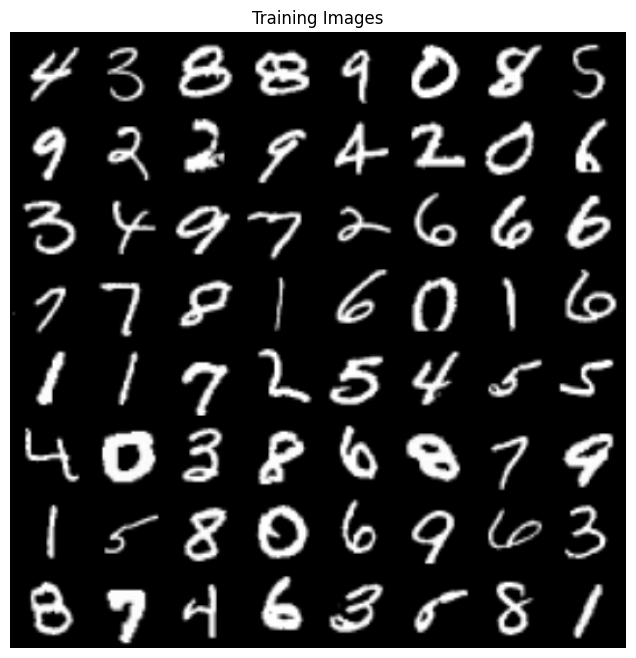

In [32]:
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

## **Weight Initialization**

All model weights shall be randomly initialized from a Normal Distribution with *mean=0*, *stdev=0.2*. The *weights_init* unction takes an initialized model as input and reinitializes all convolutional, convolutional-transpose, and batch normalization layers to meet this criteria.

In [33]:
def weights_init(layer):
    classname = layer.__class__.__name__
    
    if classname.find('Conv') != -1:
        nn.init.normal_(layer.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(layer.weight.data, 1.0, 0.02)
        nn.init.constant_(layer.bias.data, 0)

## **Generator**

$G$ is designed to map the latent space vector $z$ to data-space, meaning that $z$ is converted to RGB images of shape (3 x 64 x 64). This is accomplished through a series of strided two dimensional convolutional transpose layers, each paired with a 2d batch norm layer and ReLU activation. The output of the generator is fed through a *tanh* function to return it to the input data range of [-1, 1].

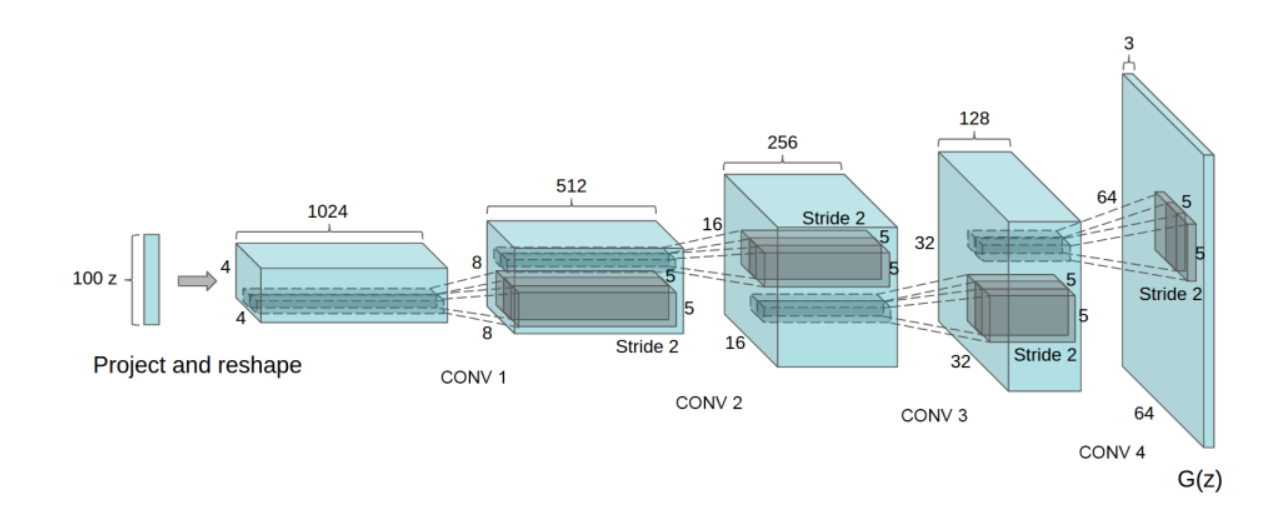

In [34]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.net = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (ngf*4) x 8 x 8
            nn.ConvTranspose2d( ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (ngf*2) x 16 x 16
            nn.ConvTranspose2d( ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.LeakyReLU(0.2, inplace=True),
            # (ngf) x 32 x 32
            nn.ConvTranspose2d( ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # (nc) x 64 x 64
        )

    def forward(self, input):
        return self.net(input)

In [35]:
generator = Generator().to(device)
generator.apply(weights_init)
print(generator)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2, inplace=True)
    (12): ConvTransp

## **Discriminator**

As mentioned, the discriminator, $D$, is a binary classification network that takes an image as input and outputs a scalar probability that the input image is real (as opposed to fake). Here, $D$ takes a 3x64x64 input image, processes it through a series of Conv2d, BatchNorm2d, and LeakyReLU layers, and outputs the final probability through a Sigmoid activation function. This architecture can be extended with more layers if necessary for the problem, but there is significance to the use of the strided convolution, BatchNorm, and LeakyReLUs. The DCGAN paper mentions it is a good practice to use strided convolution rather than pooling to downsample because it lets the network learn its own pooling function.

In [36]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.net(input)

In [37]:
discriminator = Discriminator().to(device)
discriminator.apply(weights_init)
print(discriminator)

Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)


## **Loss Functions and Optimizers**

In [38]:
# initialize the BCELoss function
criterion = nn.BCELoss()

# batch of latent vectors to visualize the progression of the generator
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# establish convention for real and fake labels during training
real_label = 1
fake_label = 0

# set up Adam optimizers for both G and D
optimizer_G = optim.Adam(generator.parameters(), lr=0.0005, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(beta1, 0.999))

## **Training**

**Train the Discriminator**

Recall, the goal of training the discriminator is to maximize the probability of correct classifying a given input as real or fake: *we wish to update the discriminator by ascending its stochastic gradient*. Practically, we want to maximize $log(D(x)) + log(1 - D(G(z)))$. Due to the **separate mini-batch** suggestion from *ganhacks*, we will calculate the gradients in two steps:

1. batch of real samples, forward through $D$, calculate loss $log D(x)$, calculate gradients in a backward pass
2. batch of fake samples, forward through $D$, calculate loss $log (1 - D(G(z)))$, accumulate gradients in a backward pass

Now with the gradients accumulated from both all-real and all-fake batches, we call a step of the Discriminator's optimizer.

**Train the Generator**

The goal of the generator is to minimize $log(1 - D(G(z)))$ in an effort to generate better fakes. This was shown by *Goodfellow* to not provide sufficient gradients, especially early in the learning process. As a fix, we instead wish to maximize $log(D(G(z)))$. In code this is accomplished by:
- classifying the Generator output with the Discriminator
- computing G's loss using *real labels as ground truth*
- computing G's gradients in a backward pass
- updating G's parameters with an optimizer step 

In [39]:
fake_noise_evolution = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")

for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):

        #############################################################
        # (1) Update D network: maximize log(D(X)) + log(1 - D(G(z)))
        #############################################################
        
        # Train With All-Real Batch
        ###########################
        discriminator.zero_grad()
        # format batch
        real_data = data[0].to(device)
        b_size = real_data.size(0)
        label = torch.full((b_size, ), real_label, dtype=torch.float, device=device)
        # forward pass real data batch through D
        output = discriminator(real_data).view(-1)
        # calculate loss on all-real batch
        loss_D_real = criterion(output, label)
        # calculate gradients for D in backward pass
        loss_D_real.backward()
        D_x = output.mean().item() 

        # Train With All-Fake Batch
        ###########################
        # format batch
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_data = generator(noise)
        label = label.fill_(fake_label)
        # forward pass fake data batch through D
        output = discriminator(fake_data.detach()).view(-1)
        # calculate loss on all-fake batch
        loss_D_fake = criterion(output, label)
        # calculate gradients for this fake batch, accumulated (summed) with previous gradients
        loss_D_fake.backward()
        D_G_z1 = output.mean().item()
        # compute error of D as sum over the fake and the real batches
        loss_D = loss_D_real + loss_D_fake
        # update discriminator
        optimizer_D.step()

        ##############################################
        # (2) Update G network: maximize log (D(G(z)))
        ##############################################
        
        generator.zero_grad()
        # fake labels are real for generator cost
        label.fill_(real_label)
        # since we just updated D, perform another forward pass of all-fake batch through D
        output = discriminator(fake_data).view(-1)
        # calculate G's loss based on this output
        loss_G = criterion(output, label)
        # compute gradients for G
        loss_G.backward()
        D_G_z2 = output.mean().item()
        # update G
        optimizer_G.step()

        if i % 50 == 0:
            print(f"[{epoch}/{num_epochs}] [{i}/{len(dataloader)}] Loss_D: {loss_D.item():.4f} Loss_G: {loss_G.item():.4f}")

        # save losses for plotting
        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

        if (iters % 500 == 0) or ((epoch == num_epochs - 1) and (i == len(dataloader) - 1)):
            with torch.no_grad():
                fake = generator(fixed_noise).detach().cpu()
            fake_noise_evolution.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

Starting Training Loop...
[0/5] [0/469] Loss_D: 1.7082 Loss_G: 1.6258
[0/5] [50/469] Loss_D: 0.7557 Loss_G: 4.0938
[0/5] [100/469] Loss_D: 1.0170 Loss_G: 1.0538
[0/5] [150/469] Loss_D: 0.7574 Loss_G: 1.0137
[0/5] [200/469] Loss_D: 0.3710 Loss_G: 2.3832
[0/5] [250/469] Loss_D: 0.4838 Loss_G: 3.1213
[0/5] [300/469] Loss_D: 0.5274 Loss_G: 1.3168
[0/5] [350/469] Loss_D: 0.3689 Loss_G: 2.4021
[0/5] [400/469] Loss_D: 1.2834 Loss_G: 0.3864
[0/5] [450/469] Loss_D: 3.2841 Loss_G: 0.0422
[1/5] [0/469] Loss_D: 0.7105 Loss_G: 1.3816
[1/5] [50/469] Loss_D: 0.6039 Loss_G: 1.4181
[1/5] [100/469] Loss_D: 0.9211 Loss_G: 1.0862
[1/5] [150/469] Loss_D: 0.2977 Loss_G: 1.9721
[1/5] [200/469] Loss_D: 1.2085 Loss_G: 2.1228
[1/5] [250/469] Loss_D: 0.8517 Loss_G: 2.8516
[1/5] [300/469] Loss_D: 0.7686 Loss_G: 1.4358
[1/5] [350/469] Loss_D: 0.5847 Loss_G: 2.0011
[1/5] [400/469] Loss_D: 1.7314 Loss_G: 2.3030
[1/5] [450/469] Loss_D: 0.6003 Loss_G: 1.5588
[2/5] [0/469] Loss_D: 0.5145 Loss_G: 2.6135
[2/5] [50/469] L

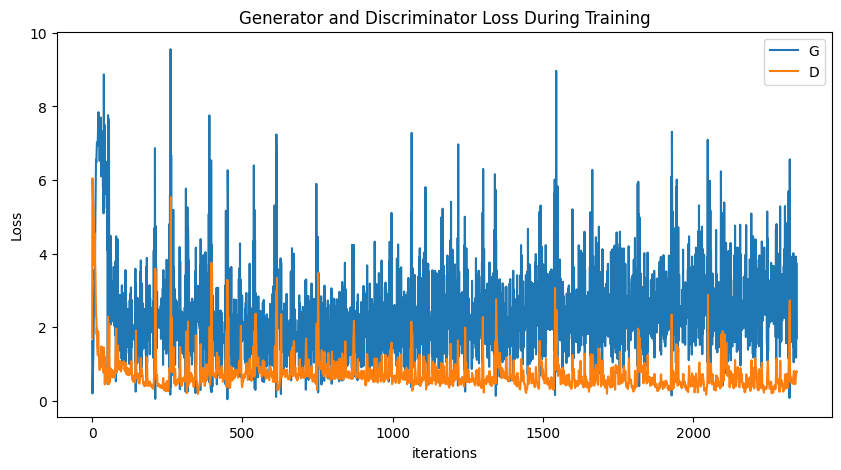

In [40]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

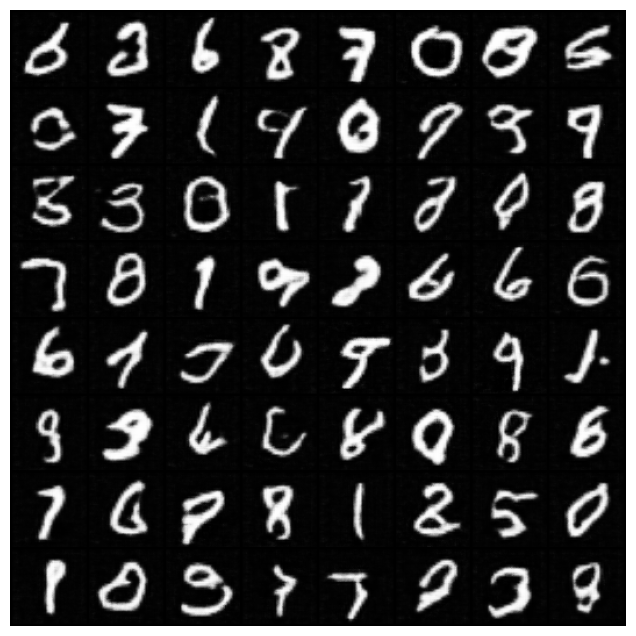

In [41]:
fig = plt.figure(figsize=(8,8))
plt.axis("off")
ims = [[plt.imshow(np.transpose(i,(1,2,0)), animated=True)] for i in fake_noise_evolution]
ani = animation.ArtistAnimation(fig, ims, interval=1000, repeat_delay=1000, blit=True)

HTML(ani.to_jshtml())

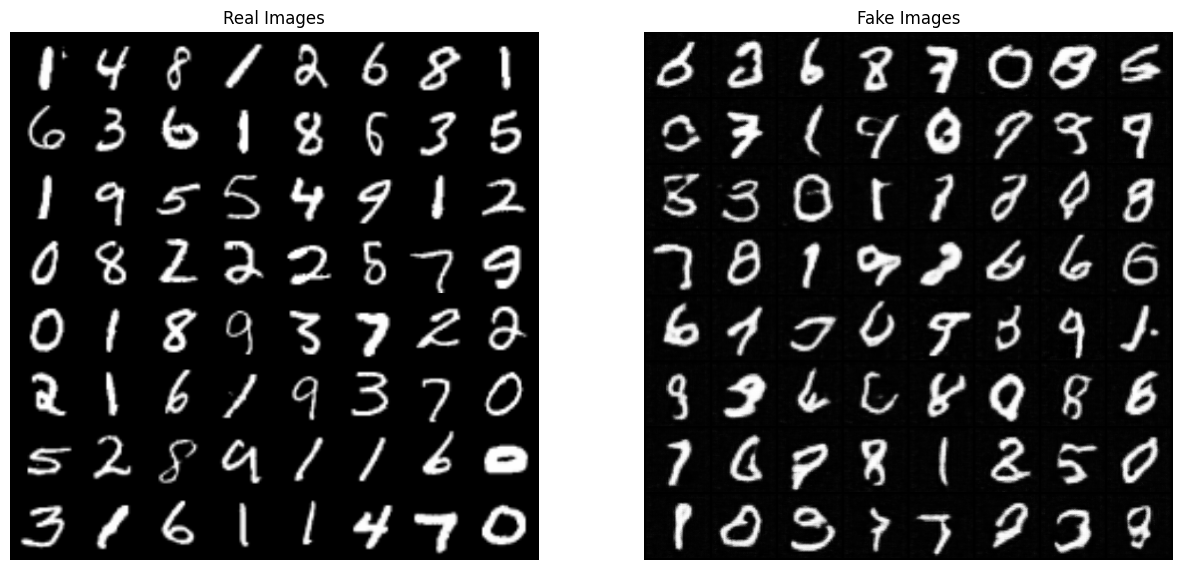

In [42]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

# Plot the real images
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

# Plot the fake images from the last epoch
plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(fake_noise_evolution[-1],(1,2,0)))
plt.show()